# Nội Dung

Thực hiện trực quan hóa dữ liệu trên tập dữ liệu về phân loại chất lượng rượu đỏ.

## Bài làm

### import thư viện cần thiết

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load dữ liệu

In [ ]:
df = pd.read_csv('../data/winequality-red.csv')
df.head(5)

FileNotFoundError: [Errno 2] No such file or directory: '/data/winequality-red.csv'

### Cái nhìn tổng quan về dữ liệu

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [ ]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [ ]:
print("Có tổng cộng {} giá trị null trong tập dữ liệu".format(df.isnull().sum().sum()))

Có tổng cộng 0 giá trị null trong tập dữ liệu


## EDA

### Biểu đồ histplot của acidity:

[Text(0.5, 1.0, 'Sự phân phối của volatile acidity')]

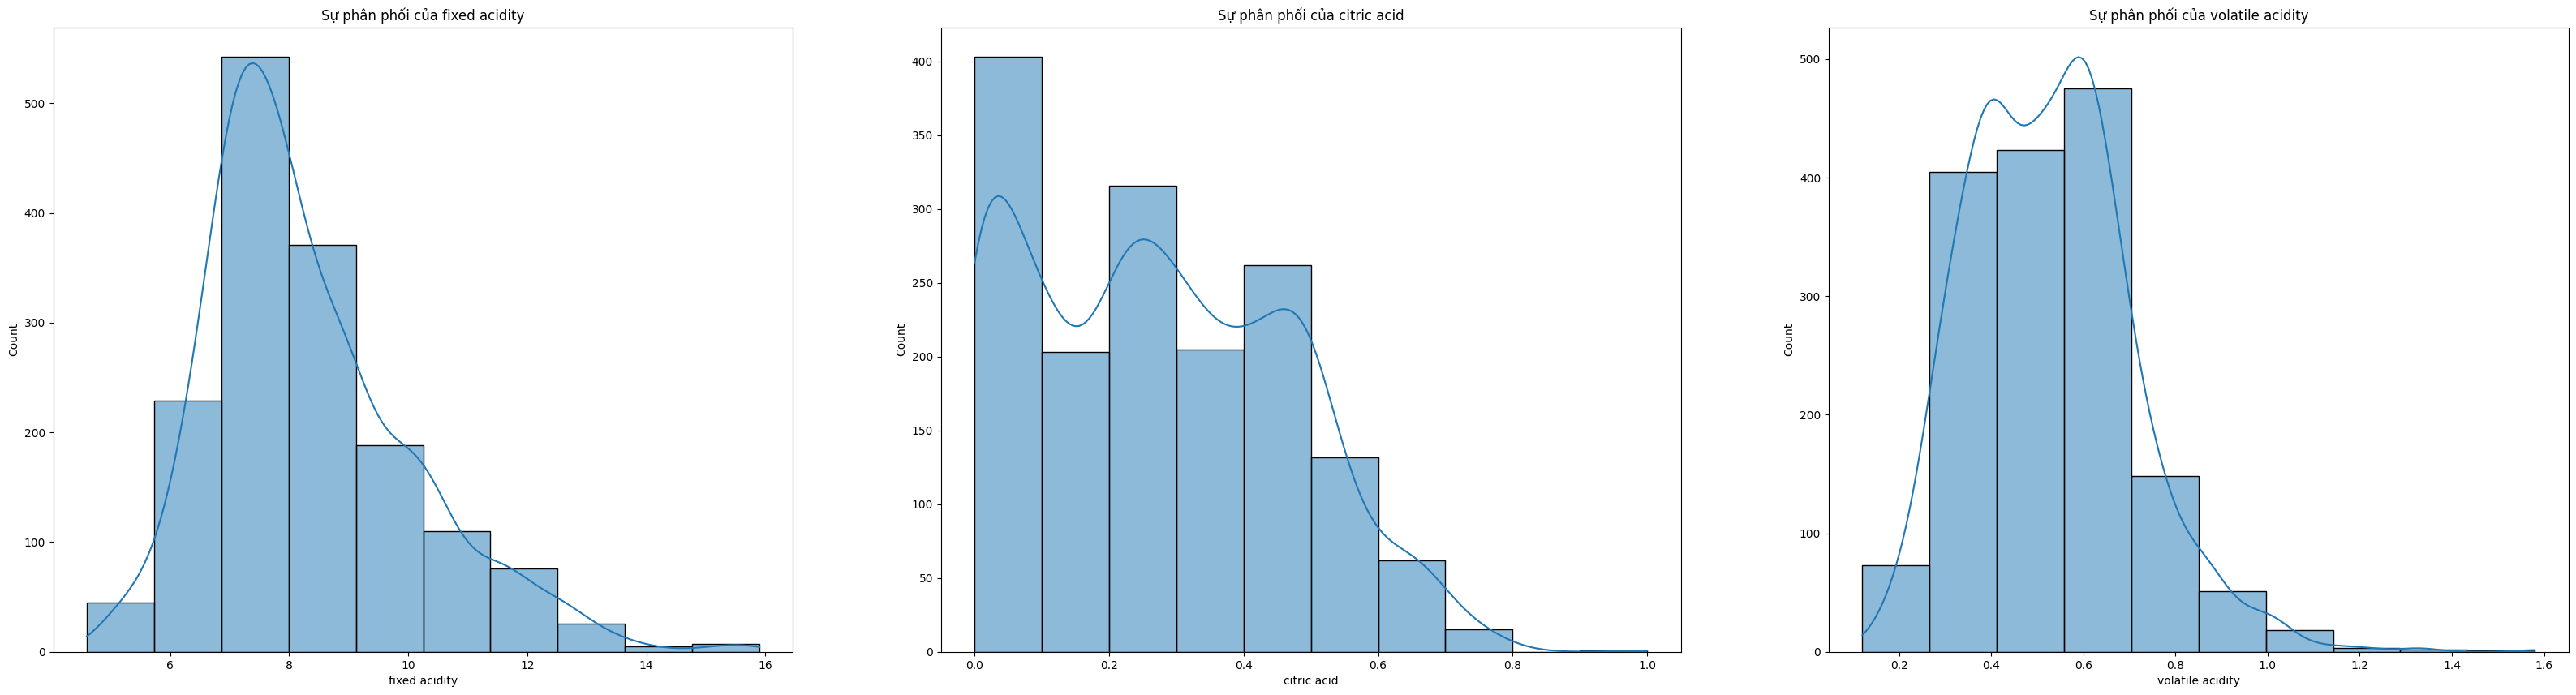

In [ ]:
fig, ax = plt.subplots(1,3,figsize=(40,10))
sns.histplot(ax = ax[0], x = df['fixed acidity'],bins = 10,kde = True,cbar = True).set(title ="Sự phân phối của fixed acidity")
sns.histplot(ax = ax[1], x = df['citric acid'],bins = 10,kde = True,cbar = True).set(title= "Sự phân phối của citric acid")
sns.histplot(ax = ax[2], x = df['volatile acidity'],bins = 10,kde = True,cbar = True).set(title="Sự phân phối của volatile acidity")

Sau khi phân tích 3 biểu đồ trên:  biểu đồ 'fixed acidity' phân phối bình thường(nhưng có một chuốt lệch về phải). Nhưng mà 2 biểu đồ còn lại là phân phối hai đỉnh (Bimodal).

[Text(0.5, 1.0, 'Sự phân phối của chlorides')]

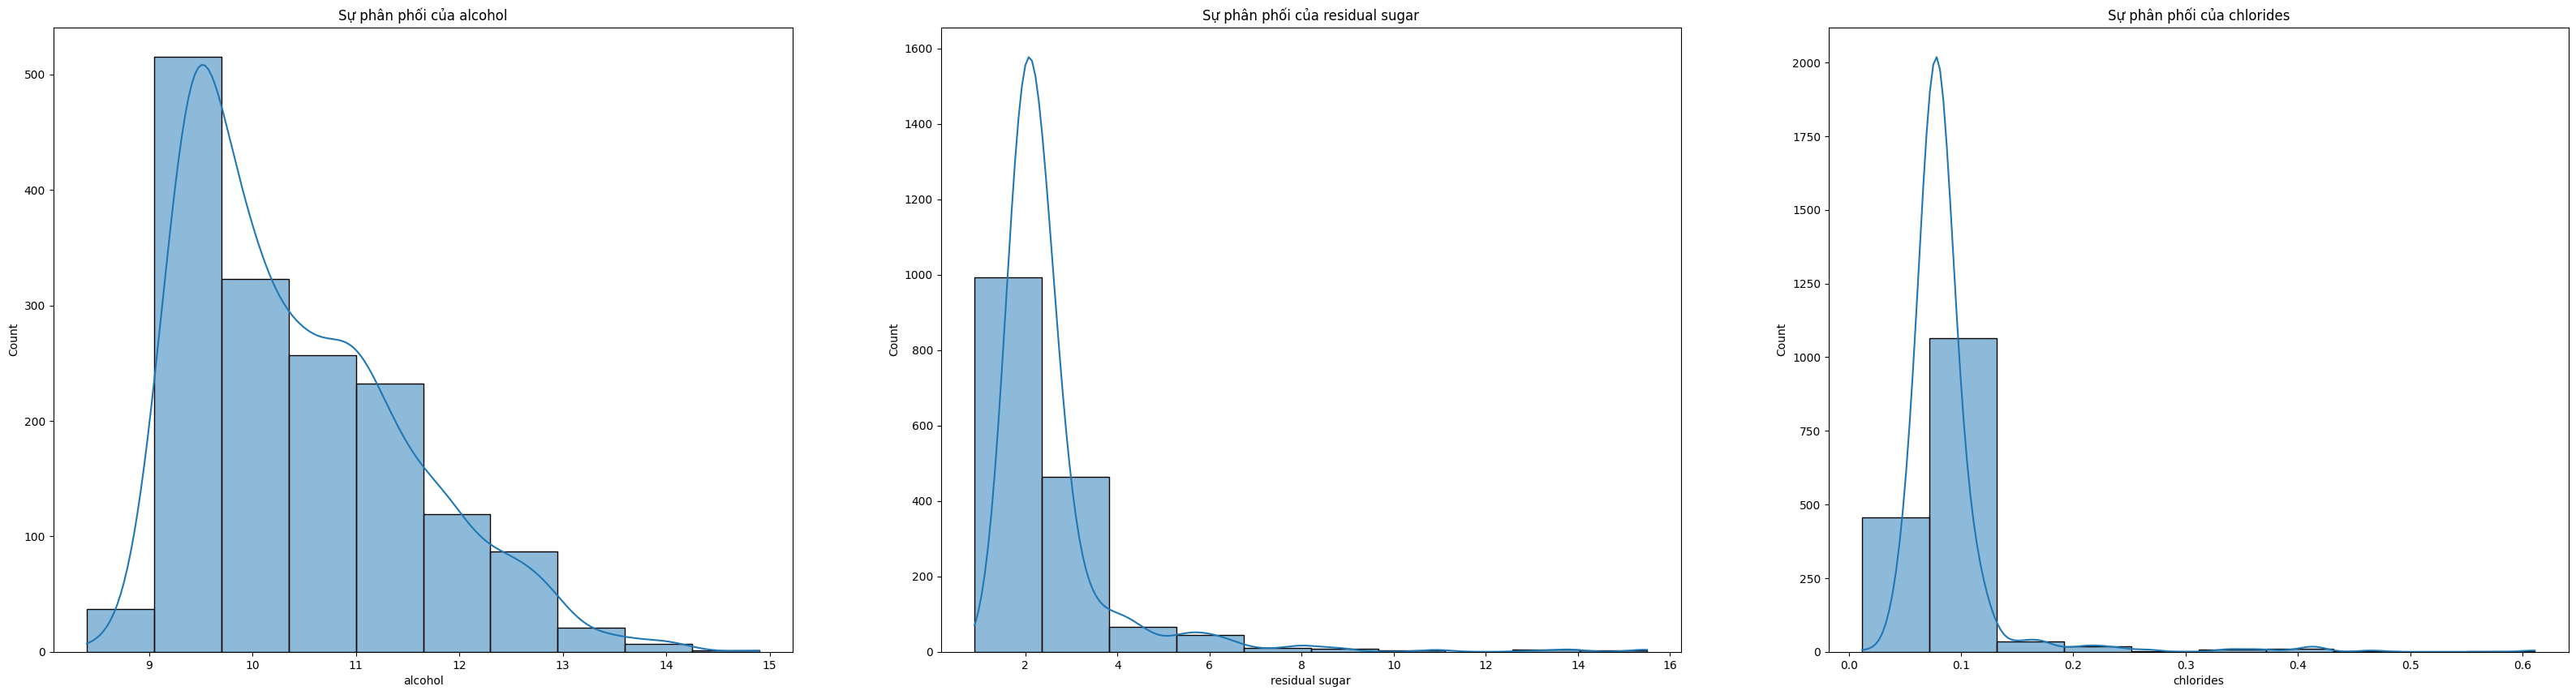

In [ ]:
fig, ax = plt.subplots(1,3,figsize=(40,10))
sns.histplot(ax = ax[0], x = df['alcohol'],bins = 10,kde = True,cbar = True).set(title ="Sự phân phối của alcohol")
sns.histplot(ax = ax[1], x = df['residual sugar'],bins = 10,kde = True,cbar = True).set(title= "Sự phân phối của residual sugar")
sns.histplot(ax = ax[2], x = df['chlorides'],bins = 10,kde = True,cbar = True).set(title="Sự phân phối của chlorides")

Phân tích 3 biểu đồ tiếp theo: 3 biến alcohol, residual sugar và chlorides đều không phân bổ bình thường

### Pairplot

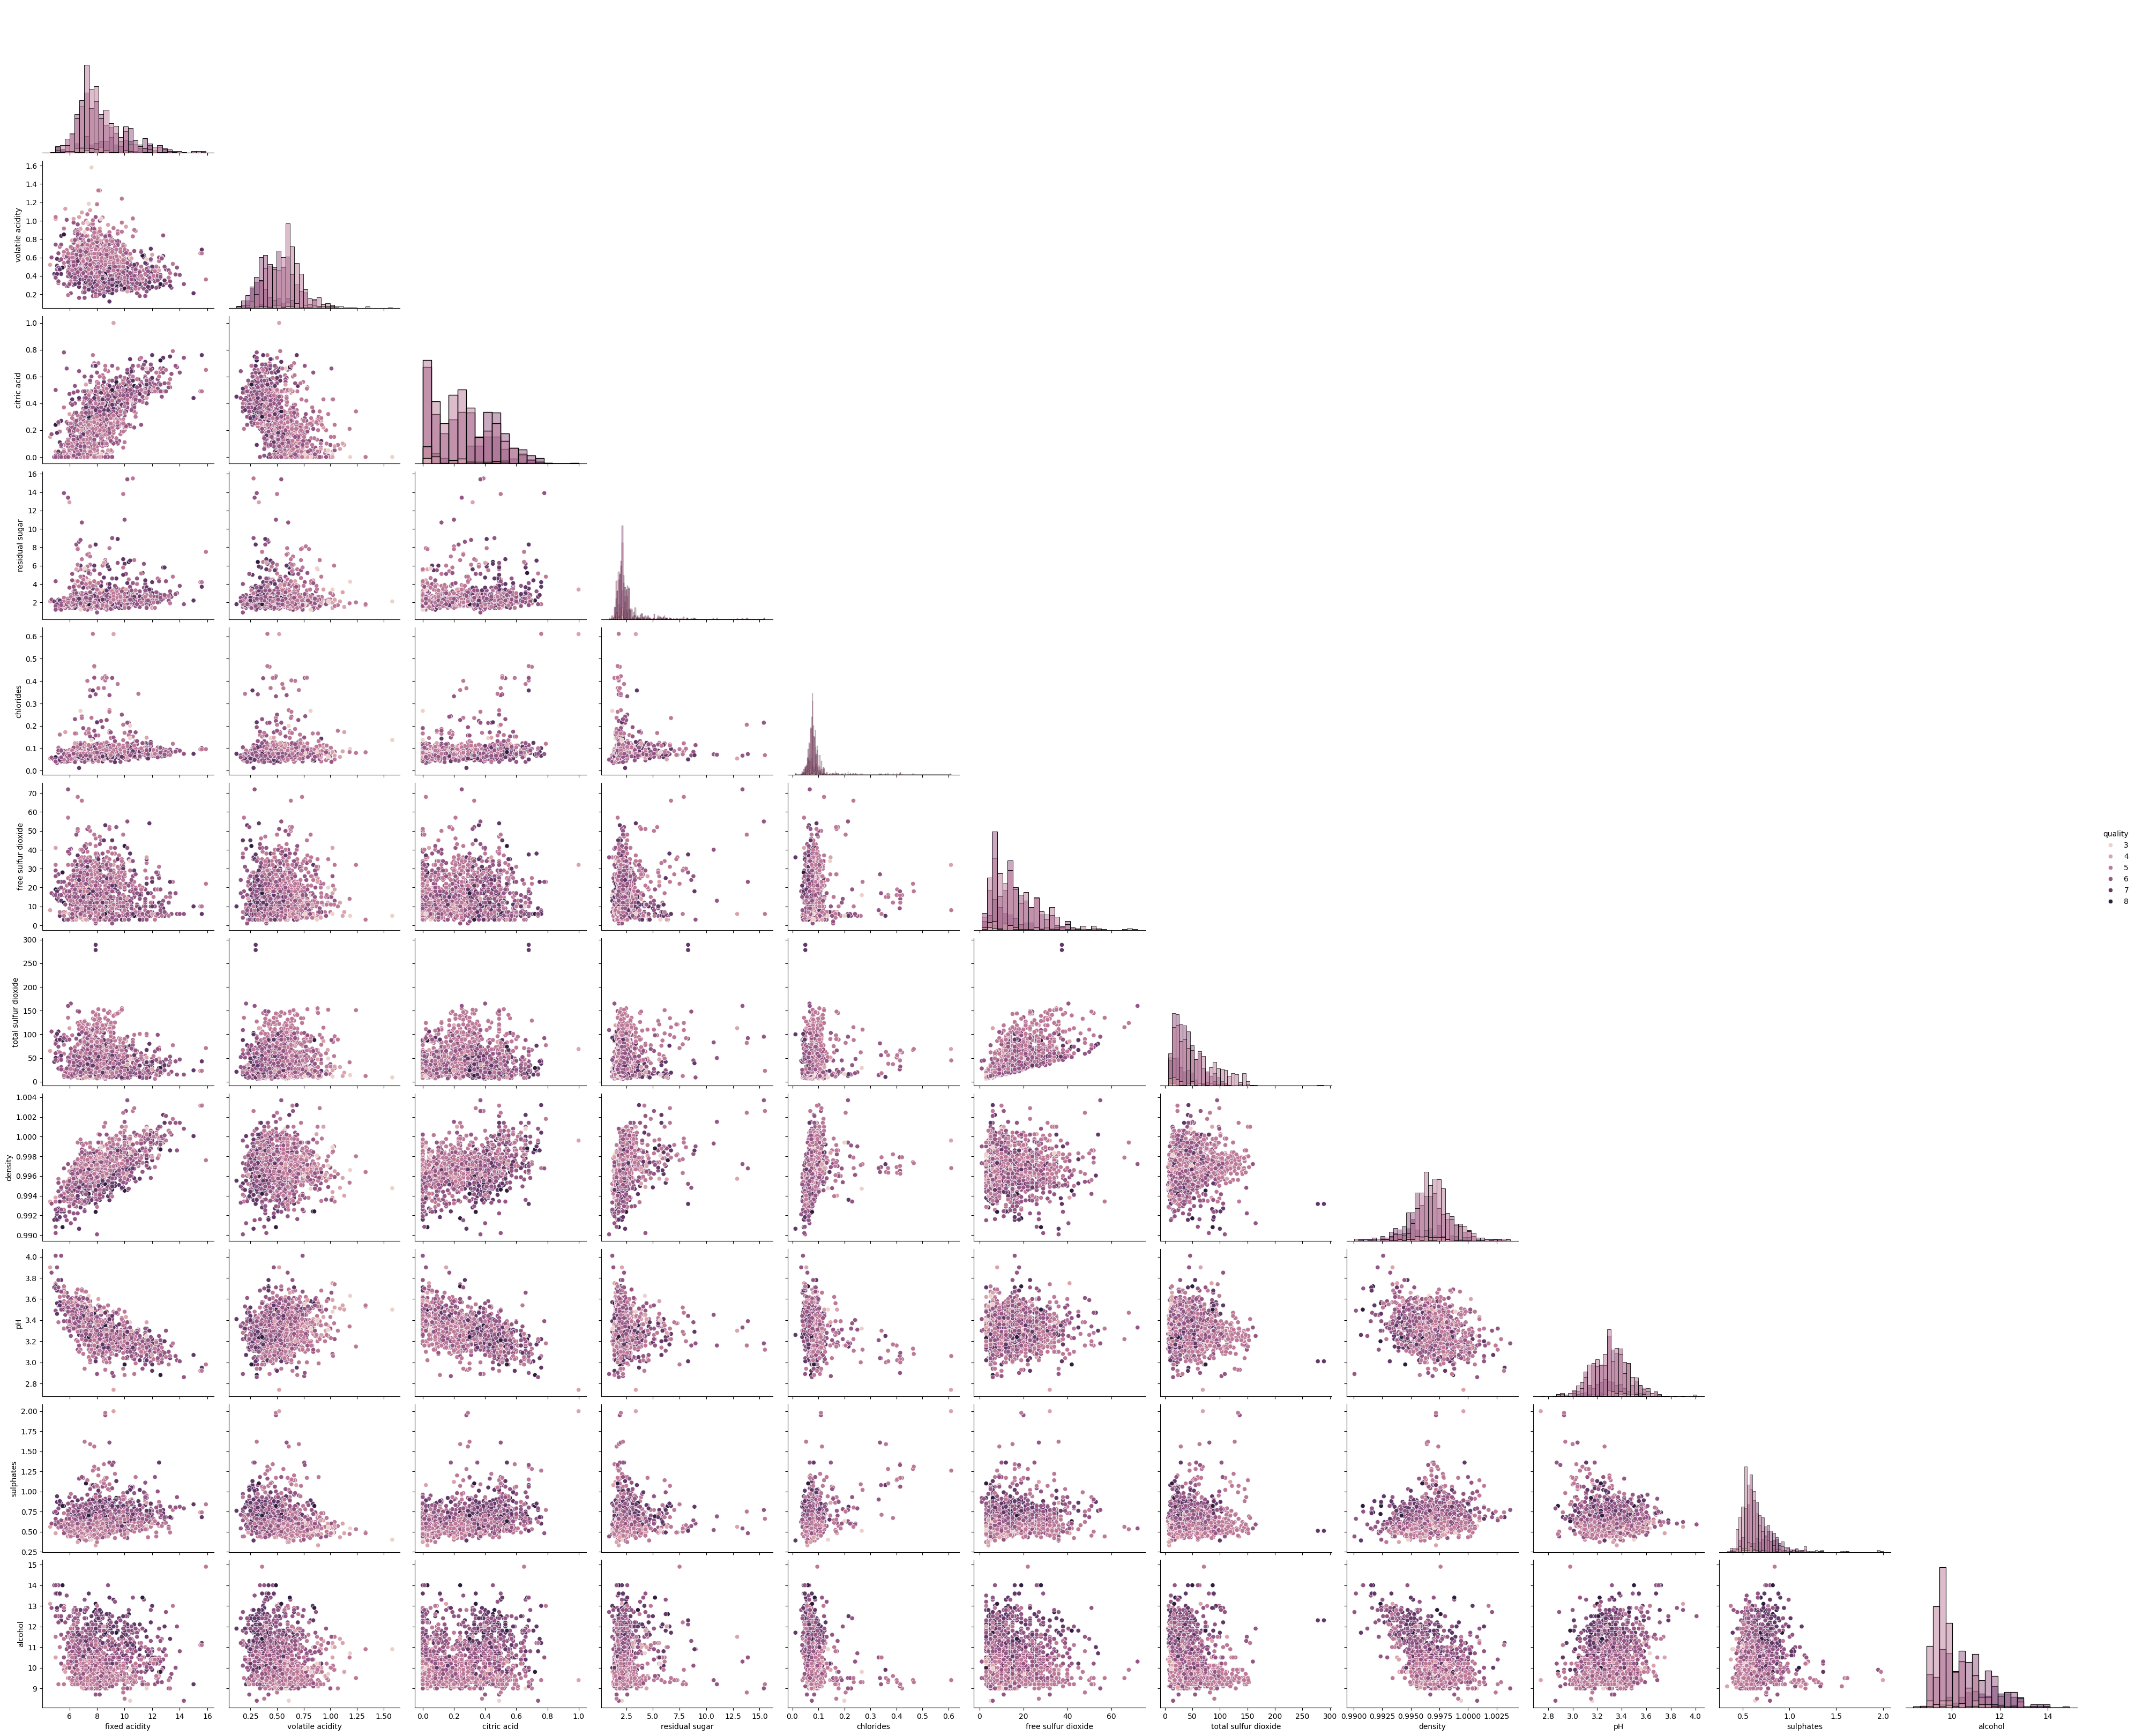

In [ ]:
sns.pairplot(df, diag_kind = "hist", hue = "quality", height = 3, aspect = 1.2, corner = True);

Dựa vào biểu đồ pairplot ta thấy sự tương quan với nhau giữa các biến độc lập. Đây là yếu tố không mong muốn. Vấn đề này gọi là hiện tượng Đa cộng tuyến (multicollinearity)

### Scatterplot

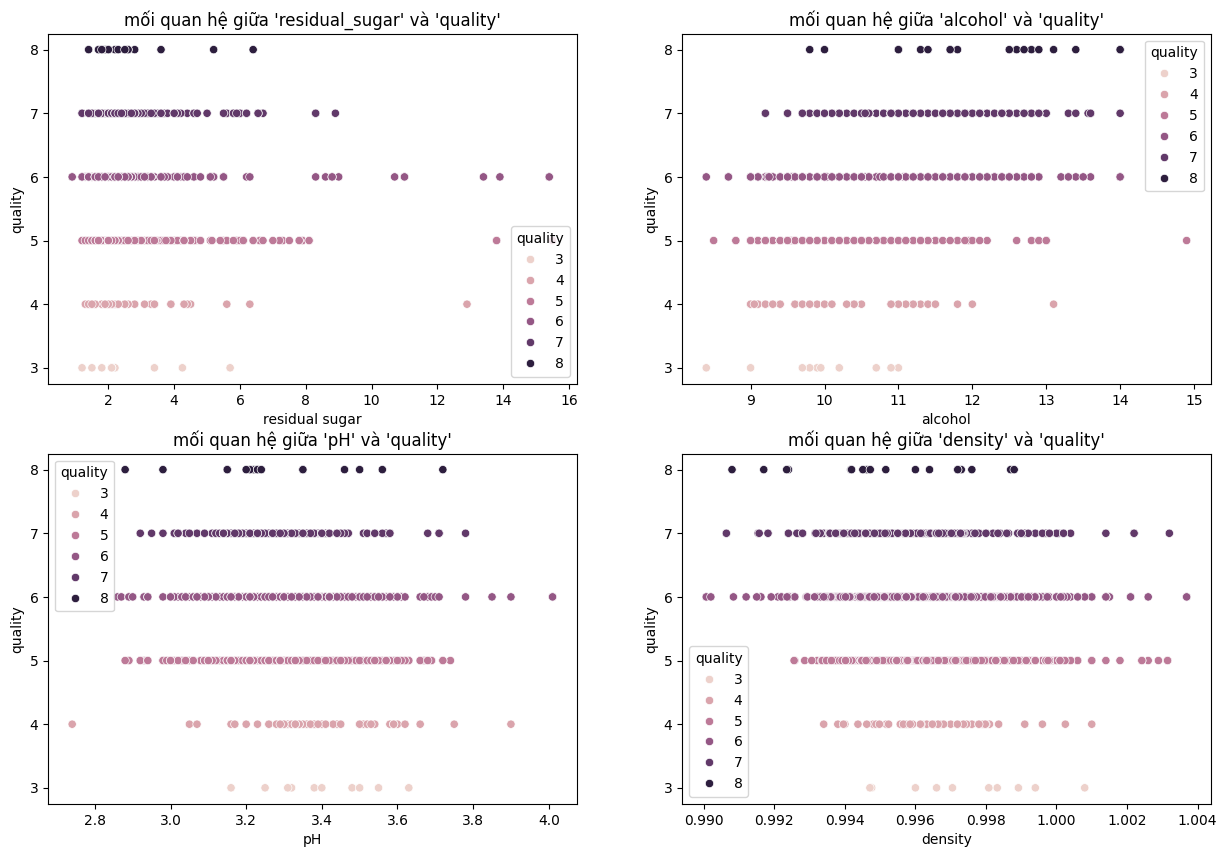

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

sns.scatterplot(ax = axes[0],
                x = "residual sugar",
                y = "quality", hue = "quality",
                data = df).set(title = "mối quan hệ giữa 'residual_sugar' và 'quality'");

sns.scatterplot(ax = axes[1],
                x = "alcohol",
                y = "quality", hue = "quality",
                data = df).set(title = "mối quan hệ giữa 'alcohol' và 'quality'");

sns.scatterplot(ax = axes[2],
                x = "pH",
                y = "quality", hue = "quality",
                data = df).set(title = "mối quan hệ giữa 'pH' và 'quality'");

sns.scatterplot(ax = axes[3],
                x = "density",
                y = "quality", hue = "quality",
                data = df).set(title = "mối quan hệ giữa 'density' và 'quality'");

Biến quality là biến phân loại (thang điểm từ 3 đến 8), các biểu đồ này cho thấy sự phân bố của các điểm chất lượng khác nhau theo từng biến.

- residual sugar:

    Các điểm dữ liệu phân tán rộng rải theo trục residual sugar ( từ 1-16). Không có xu hướng rõ ràng nào cho thấy rượu có đường dư cao hơn sẽ có chất lượng rượu tốt hơn (hoặc tệ hơn) => Biến Residual sugar không có khả năng dự đoán chất lượng theo một mối quan hệ tuyến tính đơn giản.

- alcohol:

    Các điểm có chất lượng cao hơn (màu tối, ví dụ: 7, 8) có xu hướng dịch chuyển về phía bên phải của biểu đồ (nơi có nồng độ cồn cao hơn, khoảng 11-14). Ngược lại, các điểm có chất lượng thấp (màu nhạt, ví dụ: 3, 4) tập trung ở phía có nồng độ cồn thấp hơn => Nồng độ cồn cao hơn có liên quan đến chất lượng rượu tốt hơn.

- độ pH:

    Mặc dù không rõ ràng như alcohol nhưng ta vẫn có thể thấy các điểm có chất lượng cao (7-8) nằm ở giữa khoảng (từ 3.0 -> 3.6) trong khi các điểm quality thấp (3-4) phân bố rải rác. Rất khó để nhận thấy bằng mắt thường.

- density:

    Giống với residual sugar, các mức chất lượng khác nhau gần như trải đều trên toàn bộ phạm vi density. Các điểm chất lượng cao và thấp nằm chồng chéo lên nhau, đặc biệt trong phạm vi mật độ thông thường.

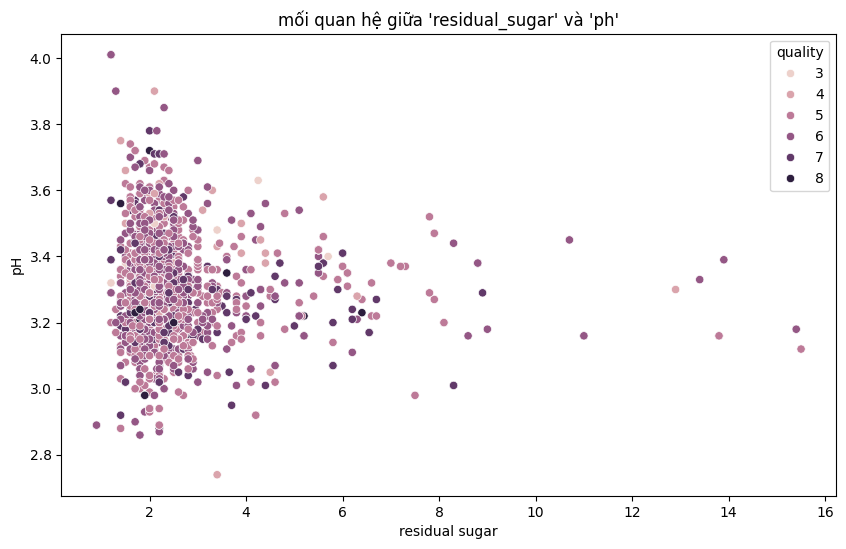

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x = "residual sugar",
                y = "pH",
                hue = "quality",data = df).set(title = "mối quan hệ giữa 'residual_sugar' và 'ph'");
plt.show()

Mối quan hệ giữa residual sugar và pH không đủ để có thể phân loại được chất lượng của rượu, do các điểm nằm rải rác, không theo một xu hướng nhất định.

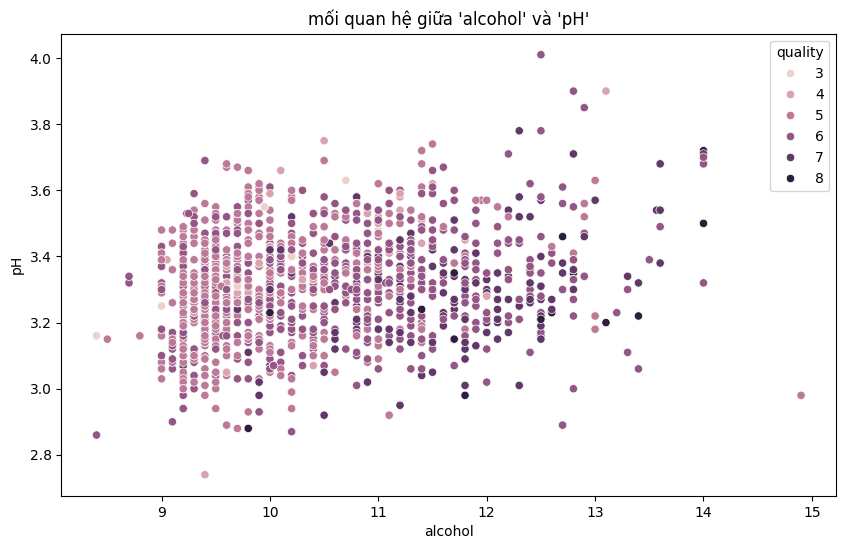

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x = "alcohol",
                y = "pH",
                hue = "quality",data = df).set(title = "mối quan hệ giữa 'alcohol' và 'pH'");
plt.show()

Cũng giống như residual sugar với pH. Thì mối quan hệ giữa alcohol và pH cũng không có sự tương quan mạnh.

### Histogram của các biến

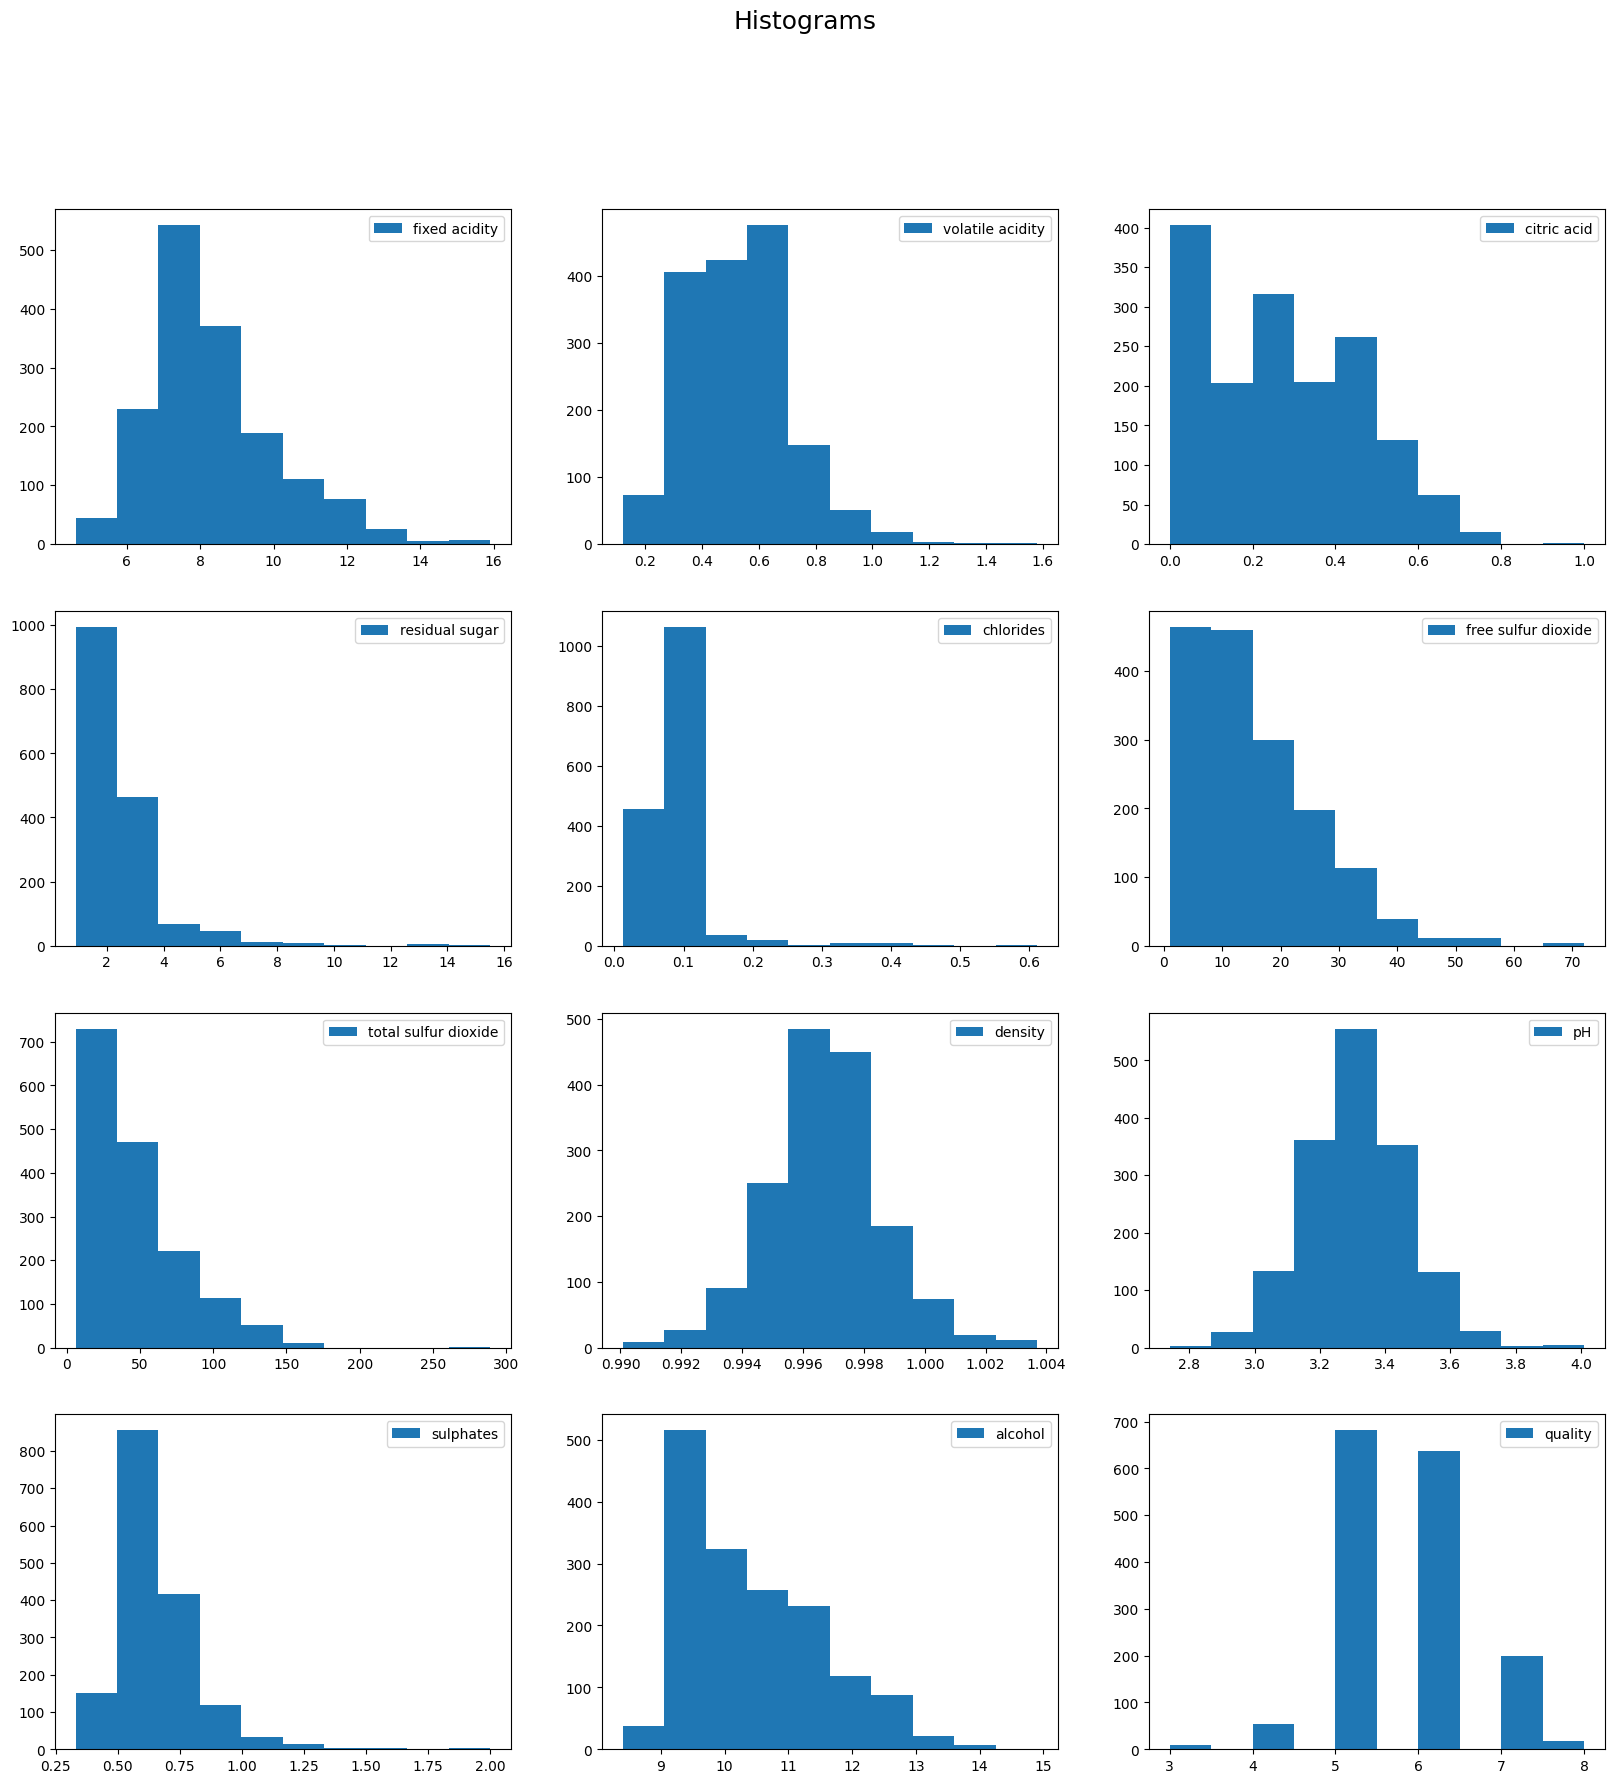

In [ ]:
fig, axes = plt.subplots(nrows = 4, ncols = 3, figsize = (20, 20))


for index, column in enumerate(df.columns):
    ax = axes.flatten()[index]
    ax.hist(df[column], label = column)
    ax.legend(loc = "best")
plt.suptitle("Histograms", size = 18)

plt.show()

Dựa vào biểu đồ ta có:

Hầu hết các giá trị của biến "fixed_acidity" nằm trong khoảng 7 - 8;

Hầu hết các giá trị của biến "volatile_acidity" nằm trong khoảng 0.4 - 0.7;

Hầu hết các giá trị của biến "citric_acid" nằm trong khoảng 0.0 - 0.1;

MHầu hết các giá trị của biến "residual_sugar" nằm trong khoảng 1 - 2.5;

Hầu hết các giá trị của biến "chlorides" nằm trong khoảng 0.085 - 0.15;

Hầu hết các giá trị của biến "free_sulfur_dioxide" nằm trong khoảng 0 - 15;

Hầu hết các giá trị của biến "total_sulfur_dioxide" nằm trong khoảng 0 - 30;

Hầu hết các giá trị của biến "density" nằm trong khoảng 0.996 - 0.998;

Hầu hết các giá trị của biến "pH" nằm trong khoảng 3.2 - 3.4;

Hầu hết các giá trị của biến "sulphates" nằm trong khoảng 0.50 - 0.75;

Hầu hết các giá trị của biến "alcohol" nằm trong khoảng 9 - 10;

Hầu hết các giá trị của biến "quality" là 5 and 6.